# SEIS 631 Choose Your Own Hypothesis #

### Author: Isaiah Thao ###

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
#Loading in CSV Files
df_branded = pd.read_csv('branded_food.csv')
df_food = pd.read_csv('food.csv')
df_nutrients = pd.read_csv('food_nutrient.csv')

C:\Users\yitho\AppData\Local\Temp\ipykernel_6204\1779421926.py:2: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_branded = pd.read_csv('branded_food.csv')
C:\Users\yitho\AppData\Local\Temp\ipykernel_6204\1779421926.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food = pd.read_csv('food.csv')


In [3]:
print(df_branded.shape,df_food.shape,df_nutrients.shape)

(1993975, 21) (1993975, 8) (25937630, 11)


## Datasets ##

This project uses three csv files from the USDA FoodCentral datasets. This section walks through the process of filtering, merging and pivoting the tables. The final table contains useful information formated for analysis.

*Branded_food* (1993975, 21): This table contains branded product information such as ingredients.

*Food* (1993975, 8): This table contains information on product description.

*Nutrients* (25937630, 11): This table contains information on product nutrients. 

## Dataframe Set-up ##

First: Filter the large *Branded* table to only contain products within the "Energy, Protein & Muscle Recovery" category. The resulting table contains 10,488 rows which is much easier to manipulate.

In [4]:
df_branded_protein = df_branded[df_branded['branded_food_category'] == 'Energy, Protein & Muscle Recovery Drinks']
print(df_branded_protein.shape)
#print(df_branded_protein.head())

(10488, 21)


Second: Merge the *Food* table to add necessary columns. There are 7 additional columns, one of which is "description".

In [5]:
df_branded_protein_food = df_branded_protein.merge(df_food, how='inner',on='fdc_id')
print(df_branded_protein_food.shape)
#print(df_branded_protein_food.head())

(10488, 28)


Third: Each row in the *nutrients* corresponds to a single nutrient for a single product. We are only interested in a few nutrients such as protein and fiber. First filter to only include nutrients of interest. Next, pivot rows into columns that contain the amount of nutrients. 

(In the *nutrients* table, nutrients are represented by a **nutrient_id** integer value. The *nutrient_map* table contains mapping information that matches ids to nutrient names. For example, protein has protein_id of 1003.)


In [6]:
nutrient_map = pd.read_csv('nutrient.csv')

def get_nutrient_id(name):
    """
    Finds the ID for a nutrient name. 
    Supports partial and case-insensitive matching.
    """
    df = nutrient_map
    # Filter for rows where the name matches (case-insensitive)
    match = df[df['name'].str.contains(name, case=False, na=False)]
    
    if not match.empty:
        # Return the ID of the first match found
        return int(match.iloc[0]['id'])
    else:
        print(f"Warning: '{name}' not found.")
        return None
    
protein_id = get_nutrient_id('protein')
print(protein_id)

# Mapping Nutrient IDs to clean, human-readable names
target_map = {
    # Macros & Energy
    1008: 'Calories',
    1003: 'Protein',
    1004: 'Total_Fat',
    1005: 'Carbohydrates',
    2000: 'Total_Sugars',
    1079: 'Fiber',
    
    # 9 Essential Amino Acids
    1210: 'Tryptophan',
    1211: 'Threonine',
    1212: 'Isoleucine',
    1213: 'Leucine',
    1214: 'Lysine',
    1215: 'Methionine',
    1217: 'Phenylalanine',
    1219: 'Valine',
    1221: 'Histidine'
}

1003


In [7]:
df__nutrients_filtered = df_nutrients[df_nutrients['nutrient_id'].isin(target_map.keys())]

df_nutrients_wide = df__nutrients_filtered.pivot(index='fdc_id', columns='nutrient_id', values='amount')

df_nutrients_wide = df_nutrients_wide.rename(columns=target_map)

df_nutrients_wide.shape

(1887170, 15)

Fourth: Before merging the nutrients table, we will select a subset of columns from the *branded* table to be included. After merging the nutrients table to the *branded* table, the final data frame contains 10488 rows and 20 columns. Each row is a unique product, and columns contain product descriptions and nutrients. 

In [8]:
cols = ['fdc_id','description','ingredients','serving_size',
       'serving_size_unit']

df_final = df_branded_protein_food[cols]

df_final = pd.merge(df_final, df_nutrients_wide, on='fdc_id', how='left')

In [9]:
print(df_final.head(),df_final.shape)

    fdc_id                                        description  \
0  1109782  COCONUT ALMOND FLAVOR ALL-IN-ONE NUTRITIONAL S...   
1  1109805  CHOCOLATE FLAVOR ALL-IN-ONE NUTRITIONAL SHAKE ...   
2  1109852  MIXED BERRY ALL-IN-ONE NUTRITIONAL SHAKE DRINK...   
3  1110412  POMEGRANATE CRANBERRY POMEGRANATE FLAVORED ENE...   
4  1110482  ORGANIC PLANT PROTEIN POWDER, SMOOTH CHOCOLATE...   

                                         ingredients  serving_size  \
0  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
1  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...          46.0   
2  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
3  INGREDIENTS: FILTERED WATER, GRAPE JUICE (WATE...         295.0   
4  CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...          27.5   

  serving_size_unit  Protein  Total_Fat  Carbohydrates  Calories  Fiber  \
0                 g    47.62      14.29          23.81     381.0    NaN   
1                 g    43.48      13.0

## Data Cleaning and Filtering ##

Now that we have a Dataframe with the desired columns and row structure, we can begin cleaning the actual data values. First, we identify NA values that may cause errors.

In [10]:
df_final.isna().sum()

fdc_id                   0
description              0
ingredients              0
serving_size            11
serving_size_unit       52
Protein                942
Total_Fat              988
Carbohydrates          918
Calories              1038
Fiber                 1688
Tryptophan           10331
Threonine            10332
Isoleucine           10327
Leucine              10333
Lysine               10327
Methionine           10327
Phenylalanine        10327
Valine               10327
Histidine            10327
Total_Sugars          1082
dtype: int64

After identifying columns with NA values, we will simply remove observations with NA proteins or calories. We do not replace the NA's because there are still many observations. In addition, some columns are dependent on other columns. For example, calories can be calculated from macronutrients. Replacing NAs with the mean calories value could incorrectly represent products that should have a much different value. 

In the amino acid columns, nearly all rows do not have a valid value. This is expected because the source of this data does not require all nutrient reporting. To preserve observations, no rows will be removed due to NA amino acid values. 


In [11]:
df_final = df_final.dropna(subset=['Protein','Calories'])

df_final.shape

(9396, 20)

## Filtering for Reasonable Observations ##

Next, we will attempt to remove energy drinks from the data set since they were previously included in the "Energy, Protein & Muscle Recovery Drinks" category. One method to accomplish this is by removing observations with low protein amounts. First, we can create a representative measure: 

$$ \text{Protein to Calories Ratio} = \frac{\text{Protein (g)} \times 4}{\text{Total Calories}} $$

This measure captures the composition of a product; how much of the calories comes from protein? We would expect protein drinks to contain a significant proportion of protein thus we will remove products they receive less than 25% of their calories from protein. In addition, we will remove rows with a ratio higher than 100% - these are observations with more than 25 grams of protein per 100 calories. This is biologically impossible because one gram of protein contains 4 calories.


In [12]:
df_final['protein_ratio'] = df_final['Protein'] * 4 / df_final['Calories']

df_final = df_final[(df_final['protein_ratio'] > 0.25) & (df_final['protein_ratio'] < 1)]
df_final['protein_ratio'].describe()

count    6766.000000
mean        0.603339
std         0.175624
min         0.250370
25%         0.470054
50%         0.615556
75%         0.746154
max         0.999540
Name: protein_ratio, dtype: float64

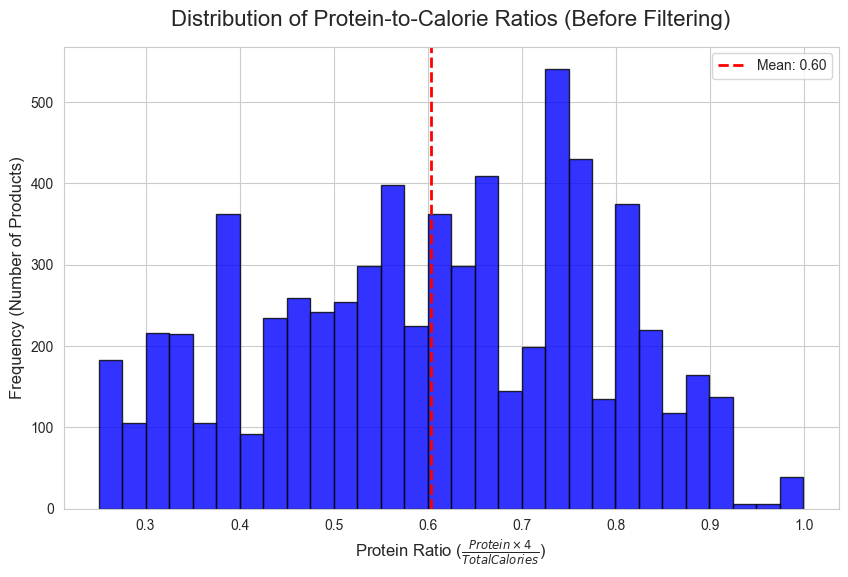

In [13]:
#Gemini
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Plotting with a nice color and black edges for clarity
plt.hist(df_final['protein_ratio'], bins=30, color='blue', edgecolor='black', alpha=0.8)

# Adding clear, descriptive labels
plt.title('Distribution of Protein-to-Calorie Ratios (Before Filtering)', fontsize=16, pad=15)
plt.xlabel(r'Protein Ratio ($\frac{Protein \times 4}{Total Calories}$)', fontsize=12)
plt.ylabel('Frequency (Number of Products)', fontsize=12)

# Optional: Add a vertical line for the average
plt.axvline(df_final['protein_ratio'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df_final["protein_ratio"].mean():.2f}')
plt.legend()

plt.show()

## Extreme Values ##

The next filtering step is to remove observations with extreme values. A simple histogram plot of calories and protein shows a right-skewed plot. In both histograms, we observed many products with low calories and low protein amounts. In addition, there are observations with extremely large amounts of calories and protein. There are a handful of more than 2000 calories or 200g of protein per serving. 

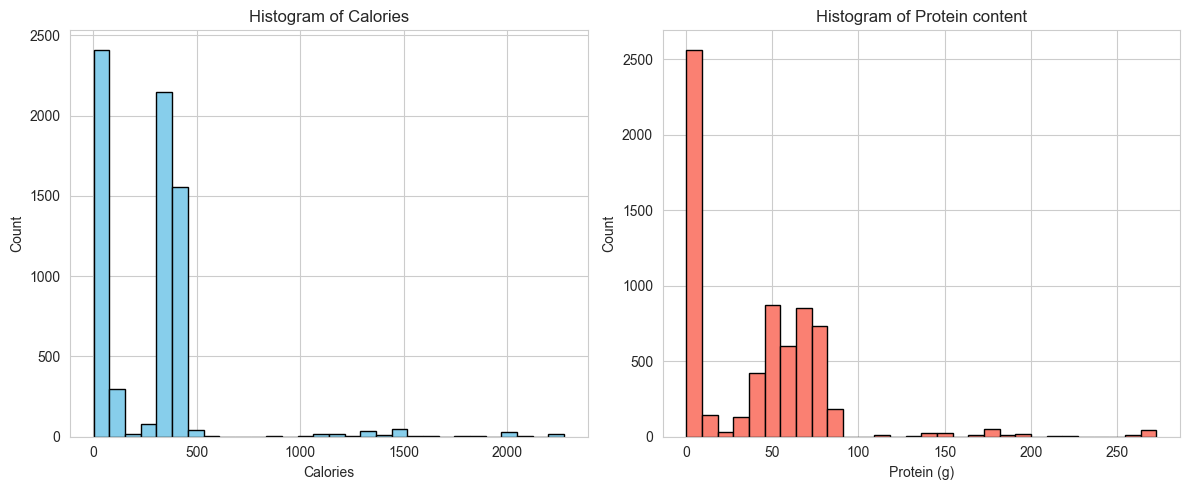

In [14]:
# Gemini: Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Calories
ax1.hist(df_final['Calories'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Histogram of Calories')
ax1.set_xlabel('Calories')
ax1.set_ylabel('Count')

# Plot 2: Protein
ax2.hist(df_final['Protein'], bins=30, color='salmon', edgecolor='black')
ax2.set_title('Histogram of Protein content')
ax2.set_xlabel('Protein (g)')
ax2.set_ylabel('Count')

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

#print(df_final['Calories'].describe())
#print(df_final['Protein'].describe())


In [15]:
df_final.nlargest(3, 'Protein')

,fdc_id,description,ingredients,serving_size,serving_size_unit,Protein,Total_Fat,Carbohydrates,Calories,Fiber,...,Threonine,Isoleucine,Leucine,Lysine,Methionine,Phenylalanine,Valine,Histidine,Total_Sugars,protein_ratio
18,1118196,"VANILLA HIGH PROTEIN SHAKE, VANILLA","WATER, PREMIER PROTEINÂ® SHAKE PROTEIN BLEND (...",330.0,ml,272.73,27.27,36.36,1455.0,9.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.09,0.749773
93,1136524,"VANILLA HIGH PROTEIN SHAKE, VANILLA","WATER, PREMIER PROTEINÂ® SHAKE PROTEIN BLEND (...",330.0,ml,272.73,27.27,36.36,1455.0,9.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.09,0.749773
1838,920518,"MAX PROTEIN NUTRITION SHAKE, MILK CHOCOLATE","WATER, MILK PROTEIN ISOLATE, CALCIUM CASEINATE...",330.0,ml,272.73,13.64,54.55,1364.0,18.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.09,0.799795


In [16]:
df_final.nlargest(3, 'Calories')

,fdc_id,description,ingredients,serving_size,serving_size_unit,Protein,Total_Fat,Carbohydrates,Calories,Fiber,...,Threonine,Isoleucine,Leucine,Lysine,Methionine,Phenylalanine,Valine,Histidine,Total_Sugars,protein_ratio
1688,887342,STRAWBERRIES & CREAM FLAVOR ALL-IN-ONE NUTRITI...,"INGREDIENTS: FILTERED WATER, ORGAIN ORGANIC PR...",330.0,ml,145.45,63.64,290.91,2273.0,18.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.09,0.255961
2347,1059511,SWEET VANILLA BEAN FLAVOR ALL-IN-ONE NUTRITION...,"INGREDIENTS: FILTERED WATER, ORGAIN ORGANIC PR...",330.0,ml,145.45,63.64,290.91,2273.0,18.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.09,0.255961
3578,1385014,STRAWBERRIES & CREAM FLAVOR ALL-IN-ONE NUTRITI...,"INGREDIENTS: FILTERED WATER, ORGAIN ORGANIC PR...",330.0,ml,145.45,63.64,290.91,2273.0,18.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.09,0.255961


Upon further investigation, the extremely large values do not appear to be errors. Products with very high calories and protein counts are products that can be described as "All-in-Ones" or "Mass Gainers". One serving of these products exceeds the average daily recommended caloric intake. Although these products contain an extreme number of calories and protein, they still have a relatively low protein ratio. We will keep these extreme values 

On the other hand, products with very small calories or proteins that still have a protein to calorie ratio greater than 25% are "recovery" products. These are products with nearly 0 calories and 0 protein amounts. For example, fdc_id 553612 contains only 4 calories but has 0.28 grams of protein resulting in a ratio of 0.28. Per the FDA guidelines, "20% DV or more protein per serving is considered high". The recommended daily protein intake is 50g thus anything greater than 10g is considered high protein. We will remove observations of less than 10g of proteins because they are not a significant source of protein.


In [17]:
df_final.nsmallest(3, 'Protein')

,fdc_id,description,ingredients,serving_size,serving_size_unit,Protein,Total_Fat,Carbohydrates,Calories,Fiber,...,Threonine,Isoleucine,Leucine,Lysine,Methionine,Phenylalanine,Valine,Histidine,Total_Sugars,protein_ratio
312,553612,THE RECOVERY DRINK,"CARBONATED WATER, NATURAL ERYTHRITOL (NATURAL ...",355.0,ml,0.28,0.0,3.38,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.28
3127,1349648,THE RECOVERY DRINK,"CARBONATED WATER, NATURAL ERYTHRITOL (NATURAL ...",355.0,ml,0.28,0.0,3.38,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.28
4601,1641820,THE RECOVERY DRINK,"CARBONATED WATER, NATURAL ERYTHRITOL (NATURAL ...",355.0,ml,0.28,0.0,3.38,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.28


In [18]:
df_final = df_final[df_final['Protein'] >= 10]
df_final.shape

(4093, 21)

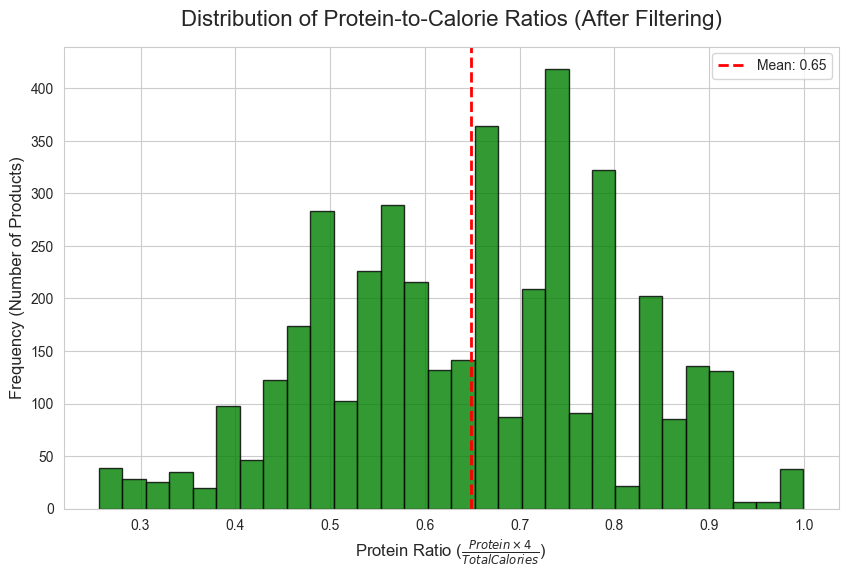

In [19]:
#Gemini
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Plotting with a nice color and black edges for clarity
plt.hist(df_final['protein_ratio'], bins=30, color='green', edgecolor='black', alpha=0.8)

# Adding clear, descriptive labels
plt.title('Distribution of Protein-to-Calorie Ratios (After Filtering)', fontsize=16, pad=15)
plt.xlabel(r'Protein Ratio ($\frac{Protein \times 4}{Total Calories}$)', fontsize=12)
plt.ylabel('Frequency (Number of Products)', fontsize=12)

# Optional: Add a vertical line for the average
plt.axvline(df_final['protein_ratio'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df_final["protein_ratio"].mean():.2f}')
plt.legend()

plt.show()

### Final Data Frame ###

After completing all filtering steps, we are left with 4093 rows to conduct analysis. A simple histogram of 'protein ratio' shows a symmetrical and normal distribution.

In addition to the existing columns, we will create a new categorical column called 'source_type' with values of either 'Plant' or 'Animal'. This column categorizes every product based on their main protein source. If a product contains a blend, it will be categorized based on the first protein source listed. The ingredients are listed in descending order by weight thus, the ingredients that appear first are the largest. Regular expressions are used to categorize ingredients then, select the category of the first occurrence. 


In [20]:
# 1. Define your keywords
animal_keywords = 'whey|casein|milk|egg|collagen|gelatin'
plant_keywords = 'pea|soy|rice|hemp|quinoa'

# 2. Define the integrated logic function
def categorize_protein(text):
    if not isinstance(text, str): 
        return 'Other'
    
    # Check for the first occurrence of each type
    animal_match = re.search(animal_keywords, text, re.IGNORECASE)
    plant_match = re.search(plant_keywords, text, re.IGNORECASE)
    
    # Get positions (infinity if not found)
    animal_pos = animal_match.start() if animal_match else float('inf')
    plant_pos = plant_match.start() if plant_match else float('inf')
    
    # Tie-breaker logic: The earlier position wins
    if animal_pos < plant_pos:
        return 'Animal'
    elif plant_pos < animal_pos:
        return 'Plant'
    else:
        return 'Other'

# 3. Apply to the dataframe
df_final['source_type'] = df_final['ingredients'].apply(categorize_protein)

# 4. Filter for final comparison
#df_final = df_final[df_final['source_type'].isin(['Animal', 'Plant'])]

In [21]:
print(df_final.shape)


(4093, 22)


## EDA ##

### Incomplete proteins ###

Not all proteins are equal. A complete protein contains all 9 amino acids essential for muscle building. Products can inflate their protein amounts by using 'filler' proteins such as collagen, wheat gluten and gelatin. These filler proteins are typically cheaper and included to provide an improved texture. Using the amino acid columns, we can determine the completeness of a protein product.

In [22]:
# 1. 9 Amino Acids 
eaas_cols = [
    'Histidine', 'Isoleucine', 'Leucine', 'Lysine', 
    'Methionine', 'Phenylalanine', 'Threonine', 'Tryptophan', 'Valine'
]

# 2. Check if all specified columns are greater than 0 for each row
# .all(axis=1) ensures EVERY column in the list meets the condition
df_final['is_complete'] = (df_final[eaas_cols] > 0).all(axis=1)

counts = df_final['is_complete'].value_counts()
proportion = df_final['is_complete'].mean()

print(counts.to_string(header=False)) 
print(f"Total Proportion: {proportion:.2%}")
print(f"Proportion based on: {df_final.groupby('source_type')['is_complete'].mean()}")



False    3947
True      146
Total Proportion: 3.57%
Proportion based on: source_type
Animal    0.028873
Other     0.006667
Plant     0.046564
Name: is_complete, dtype: float64


After labeling observations, we find that only 3.57% of the protein products in the data set report a full amino acid profile. This does not mean that only 3.57% of all the products are complete but, only 3.57% of the products reported a complete amino acid profile. In addition, when we group by source type, we find that plant-based protein drinks have a higher proportion of completeness. These values fail to capture the true proportions because we are limited by the data. We would expect animal-based protein drinks to have a higher proportion. A possible reason why plant-based appears to have a higher proportion is because isolated plant proteins are incomplete thus, products explicitly report their amino acid profile when they are complete. It is difficult to determine the true proportion of products that contain a complete protein because of lack of regulations and data missing NOT at random. Products without a complete protein profile are likely to omit nutrients to hide low-quality ingredients. 

In [23]:
# 1. Define specific "Incomplete" markers
# We exclude things that are commonly part of a 'complete blend' here
standalone_incomplete = r'(gelatin|collagen|wheat gluten|zein)'

# 2. Define Complementary Blends (The "Rice and Beans" logic)
# This regex looks for BOTH terms in any order
pea_rice_blend = r'(?=.*pea protein)(?=.*(rice protein|brown rice|grain))'
legume_grain_blend = r'(?=.*(lentil|bean|chickpea))(?=.*(rice|wheat|barley|oats))'

# 3. Create the Logic
# Flag as True if it has a 'standalone incomplete' OR (has an incomplete source AND lacks its partner)
def determine_completeness(text):
    if pd.isna(text): return False
    text = text.lower()
    
    # Check for high-quality overrides first
    if any(x in text for x in ['whey', 'soy', 'egg', 'milk', 'casein', 'beef']):
        return False # It's complete
        
    # Check for successful blends
    if pd.Series(text).str.contains(pea_rice_blend, regex=True).iloc[0]:
        return False # The blend made it complete
    
    if pd.Series(text).str.contains(legume_grain_blend, regex=True).iloc[0]:
        return False # The blend made it complete

    # Finally, check for the incomplete markers
    incomplete_markers = r'(gelatin|collagen|gluten|pea protein|rice protein|lentil|bean)'
    return pd.Series(text).str.contains(incomplete_markers, regex=True).iloc[0]

# Apply to your dataframe
df_final['incomplete_flag'] = df_final['ingredients'].apply(determine_completeness)

print(f"Proportion of products with incomplete protein profiles: {df_final['incomplete_flag'].mean():.2%}")

print(df_final.groupby('source_type')['incomplete_flag'].mean())

C:\Users\yitho\AppData\Local\Temp\ipykernel_6204\3637704306.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.Series(text).str.contains(pea_rice_blend, regex=True).iloc[0]:
C:\Users\yitho\AppData\Local\Temp\ipykernel_6204\3637704306.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if pd.Series(text).str.contains(legume_grain_blend, regex=True).iloc[0]:
C:\Users\yitho\AppData\Local\Temp\ipykernel_6204\3637704306.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return pd.Series(text).str.contains(incomplete_markers, regex=True).iloc[0]


Proportion of products with incomplete protein profiles: 17.66%
source_type
Animal    0.010999
Other     0.000000
Plant     0.396934
Name: incomplete_flag, dtype: float64


While not as accurate as the amino acid method, we can determine if a product has a complete protein profile by analyzing the ingredients. Iterating through the ingredients list, we can flag incomplete sources of protein. Plant proteins such as rice and peas lack the necessary amino acids on their own but, in blends they can create a complete profile. With the help of Gemini AI, we create a function that uses regular expressions to determine if a product contains a complete protein profile. This method is an optimistic approach. If a product includes **at least** one complete protein it will be labeled as complete. Many products contain a combination of incomplete and complete sources. We are limited by the data because it does not provide information on the amounts of each ingredient. In addition, this method does not include every complex blend combination, the estimate should be used with caution.

Using the ingredients method, the resulting proportion of products that have an incomplete protein profile is **18.34%**. In context, 18.34% of protein drinks, with more than 10g of protein, do not actually contain a complete protein profile. These products could be misleading for consumers - proteins in these drinks are not biologically usable for building muscle. Below are three products that have incomplete protein profiles. These products have more than 40g of protein which would qualify as "high protein" but, the actual amount of useable protein is unknown. 

One interesting observation when we use this method to group by source type, we find that almost 40% of the plant drinks are not complete. This high proportion could be caused by inaccuracies in our method but still demonstrate a large disparity. According to this method, only 1% of animal sourced protein drinks are incomplete. 

In [24]:
df_final[df_final['incomplete_flag'] == True].head(3)

,fdc_id,description,ingredients,serving_size,serving_size_unit,Protein,Total_Fat,Carbohydrates,Calories,Fiber,...,Lysine,Methionine,Phenylalanine,Valine,Histidine,Total_Sugars,protein_ratio,source_type,is_complete,incomplete_flag
0,1109782,COCONUT ALMOND FLAVOR ALL-IN-ONE NUTRITIONAL S...,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,47.62,14.29,23.81,381.0,NaN,...,NaN,NaN,NaN,NaN,NaN,2.38,0.499948,Plant,False,True
1,1109805,CHOCOLATE FLAVOR ALL-IN-ONE NUTRITIONAL SHAKE ...,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...",46.0,g,43.48,13.04,28.26,370.0,15.2,...,NaN,NaN,NaN,NaN,NaN,2.17,0.470054,Plant,False,True
2,1109852,MIXED BERRY ALL-IN-ONE NUTRITIONAL SHAKE DRINK...,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,47.62,14.29,21.43,381.0,14.3,...,NaN,NaN,NaN,NaN,NaN,2.38,0.499948,Plant,False,True


The purpose of this EDA is to highlight possible differences in completeness between plant-based and animal-based protein drinks. The actual figures and values are not accurate because it is limited by the data. This simply demonstrates the need for transparency in the protein supplement industry. Companies can market misleading products as "high protein" but protein is much more complex than just a number. It is important to research ingredients and protein profiles before ingesting protein drinks, especially plant-based drinks.

## Hypothesis Testing ##



In this section we will conduct a hypotheis test to identify if there is a true difference in the mean protein-ratio between plant-based and animal-based protein drinks. 

In [25]:
def mean_diff(df):
    means = df.groupby('source_type')['protein_ratio'].mean()
    return means['Animal'] - means['Plant']

In [26]:
obs_mean = mean_diff(df_final)
print(obs_mean)

0.11573863240179483


The observed difference in means of animal-based vs plant-based is 0.11. In this data, Animal-based protein drinks have a higher mean ratio than plant-based. We can use permutation testing to identify if this difference is due to randomness. 

*Test Statistic:* The difference in mean protein ratios (Animal - Plant).

*Null Hypothesis:* There is no difference in the mean protein ratio between plant-based and animal-based protein drinks.

*Alternative Hypothesis:* There is difference in the mean protein ratio between plant-based and animal-based protein drinks. This is a two-tailed test because plant proteins could have a greater or smaller protein ratio. 

The permutation test works by simulating data under the null hypothesis. To create data under the null, we reshuffle the *source_type* column. By shuffling, we randomly match difference sources to a protein ratio observation. Then, we calculate the mean difference between source types of that single reshuffling. These steps are then repeated many times to generate a null distribution. We can then compare how likely our observed effect is to occur compared to the null distribution.

In [27]:
replicates = df_final.copy()
source_sim = df_final['source_type'].tolist()
test_results = []

for i in range(5000):
    np.random.shuffle(source_sim)
    replicates['source_type'] = source_sim
    test_results.append(mean_diff(replicates))


replicates = pd.DataFrame({'replicates':test_results})

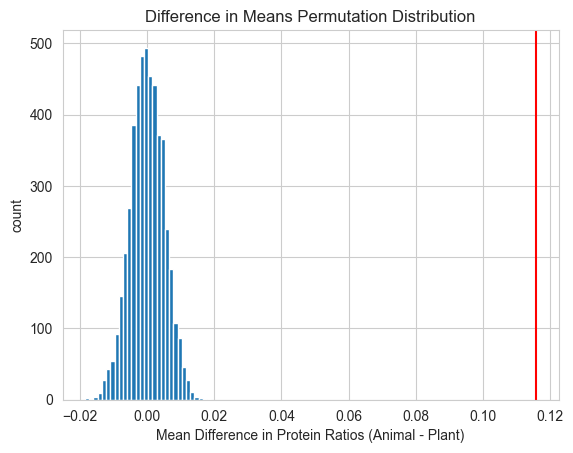

In [28]:
plt.hist(replicates['replicates'], bins = 30)
plt.axvline(obs_mean, color = 'red')
plt.title('Difference in Means Permutation Distribution')
plt.xlabel('Mean Difference in Protein Ratios (Animal - Plant)')
plt.ylabel('count')
plt.show()

In [29]:
p_value = np.mean(replicates['replicates'] >= obs_mean)
print(f'P-value after 5,000 permutations:{p_value:.2f}')

print((replicates['replicates'] >= obs_mean).sum())
print(replicates['replicates'].describe())

stds_away = ((obs_mean - np.mean(replicates['replicates'])) / np.std(replicates['replicates']))

print(f'Standard deviation: {np.std(replicates['replicates'])}')
print(f'The observed mean is {stds_away:.2f} standard deviations from the distribution mean')

P-value after 5,000 permutations:0.00
0
count    5000.000000
mean        0.000032
std         0.005004
min        -0.018397
25%        -0.003349
50%        -0.000030
75%         0.003522
max         0.019130
Name: replicates, dtype: float64
Standard deviation: 0.005003570763525364
The observed mean is 23.12 standard deviations from the distribution mean


### Permutation Test Results ###

After conducting 5,000 permutations, we result in a **p-value of 0.00**. This result is not surprising because it is generally well known that animal proteins are denser. With a p-value less than the significance threshold of 0.05, we reject the null hypothesis. The observed difference in means is likely not due to randomness. In context, animal-based proteins may be better source of proteins if you are trying to minimize extra calories. 

## Bootstrapping ## 

In this section we will conduct two bootstraps to generate 95% confidence intervals around statistics of interest. The first bootstrap will use a statistic that demonstrates the Central Limit Theorem while the second will not. 

### Confidence Interval for Difference in Mean Fiber ###

Plant-based proteins typically contain a high amount of fiber. Animal-based proteins typically contain no or little amounts of fiber. We are interested in how much more fiber plant-based proteins provide than animal-based proteins. The statistic that we will be analyzing is the difference in mean amount of fiber between the two source types. Bootstrapping will allow us to construct a range of reasonable values where we expect the true statistic to be. 

In [30]:
#Create two groups
plant_fiber = df_final[df_final['source_type'] == 'Plant']['Fiber'].dropna()
animal_fiber = df_final[df_final['source_type'] == 'Animal']['Fiber'].dropna()

# 2. Bootstrapping parameters
n_sim = 10000
boot_diffs = []

# 3. Resampling
for _ in range(n_sim):
    # Resample with replacement (same size as original groups)
    boot_plant = np.random.choice(plant_fiber, size=len(plant_fiber), replace=True)
    boot_animal = np.random.choice(animal_fiber, size=len(animal_fiber), replace=True)
    
    # Calculate difference in means for this iteration
    boot_diffs.append(np.mean(boot_plant) - np.mean(boot_animal))

# 4. Calculate 95% Confidence Interval
conf_interval = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = np.mean(plant_fiber) - np.mean(animal_fiber)

print(f"Observed Mean Difference: {observed_diff:.2f}g")
print(f"95% Confidence Interval: [{conf_interval[0]:.2f}, {conf_interval[1]:.2f}]")


Observed Mean Difference: 3.45g
95% Confidence Interval: [2.91, 3.97]


We begin conducting the bootstrap by creating a subset of two groups for animal and plant source types. Next, we randomly sample the subsets with replacement until we reach the same size as the original subsets. Then, we calculate the mean fiber difference by subtracting the mean values of each group. Finally, we repeat these steps 10,000 times and plot the boot samples. 

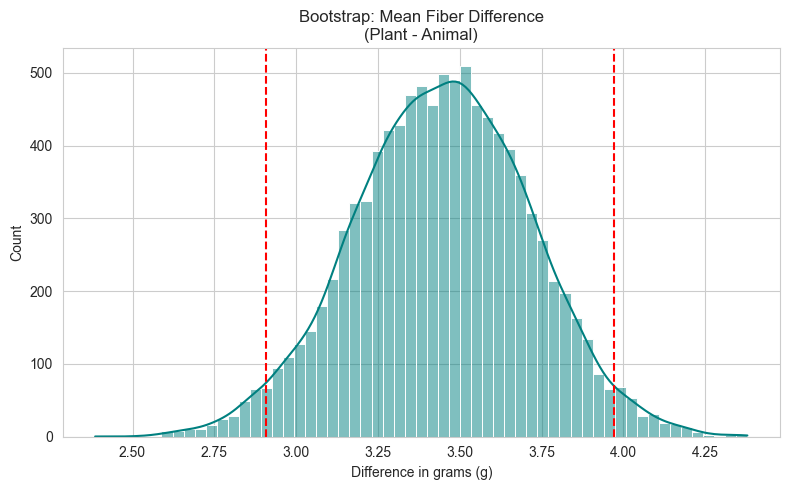

In [31]:
# Fiber Mean Difference plot
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.histplot(boot_diffs, kde=True, ax=ax1, color='teal')
ax1.set_title('Bootstrap: Mean Fiber Difference\n(Plant - Animal)')
ax1.axvline(np.percentile(boot_diffs, 2.5), color='red', linestyle='--')
ax1.axvline(np.percentile(boot_diffs, 97.5), color='red', linestyle='--')
ax1.set_xlabel('Difference in grams (g)')

plt.tight_layout()
plt.show()


A 95% confidence interval includes the middle 95% of boot sample observations, centered around the actual observed difference. We are 95% confident the true difference in mean fiber between plant-based and animal-based protein drinks is between 2.93 and 3.97 grams. In context, plant-based protein drinks provide 3-4 grams more fiber. If you prioritize fiber intake, plant-based protein drinks are a great alternative. 


This Bootstrap distribution follows the Central Limit Theorem because it uses the *sample mean* and meets the assumptions: 

1. Randomization - Random sampling from original data.
2. Independence - Fiber amounts in one product do not directly affect the amount in another.
3. Large Sample size - General rule is n >= 30. There are 4093 rows which is more than sufficient.
4. Finite Variance - Products cannot have an infinite amount of fiber thus, variance is limited

After 10,000 resamples, the bootstrap distribution closely follows the shape of a normal distribution as expected.

## Boostrapping Difference of Median number of Ingredients ##

The next statistic that we will be bootstrapping is the difference in median count of ingredients. We are interested in whether plant or animal products contain more or less ingredients than another. More ingredients could indicate a product is more processed. Products with less ingredients are typically marketed as more "natural". 

In [32]:
# Split by comma and count the items
df_final['ingredient_count'] = df_final['ingredients'].str.split(',').str.len()
print(df_final.shape)


(4093, 25)


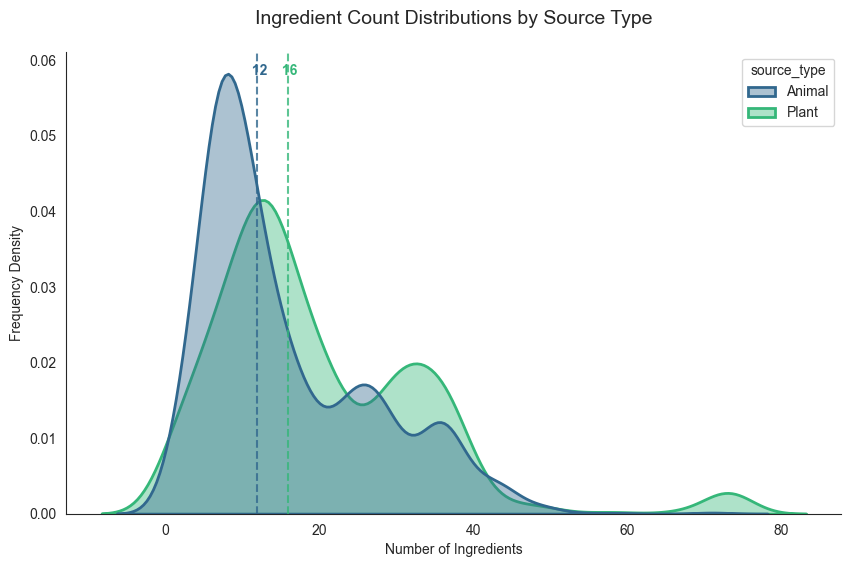

In [33]:
# 1. Calculate medians to order the categories and for labeling
medians = df_final[df_final['source_type'].isin(['Plant','Animal'])].groupby('source_type')['ingredient_count'].median().sort_values()
order = medians.index.tolist()

# 2. Set the visual style
plt.figure(figsize=(10, 6))
sns.set_style("white")

# 3. Create the overlapping KDE (Kernel Density Estimate) plot
plot = sns.kdeplot(
    data=df_final, 
    x='ingredient_count', 
    hue='source_type', 
    hue_order=order,
    fill=True, 
    common_norm=False, 
    palette='viridis', 
    alpha=0.4, 
    linewidth=2
)

# 4. Add vertical dashed lines at the median for each group
colors = sns.color_palette('viridis', len(order))
for i, (source, median_val) in enumerate(medians.items()):
    plt.axvline(median_val, color=colors[i], linestyle='--', alpha=0.8, linewidth=1.5)
    # Add a text label above the line
    plt.text(median_val, plt.ylim()[1]*0.95, f' {median_val:.0f}', 
             color=colors[i], fontweight='bold', ha='center')

plt.title('Ingredient Count Distributions by Source Type', fontsize=14, pad=20)
plt.xlabel('Number of Ingredients')
plt.ylabel('Frequency Density')
sns.despine()
plt.show()


#### Median Statistic ####

We chose median because it is a robust statistic. Robust statistics are not easily influenced by outliers in either direction. Plotting the counts of ingredients, we observe a right skewed graph. In addition, there are outliers with more than 40 ingredients. The median is a better representation than mean because it is not influenced by extreme observations. Typically, consumers are not purchasing products with a very high ingredient list (60+). 

In [34]:
# 1. Create groups 
plant_counts = df_final[df_final['source_type'] == 'Plant']['ingredient_count'].dropna()
animal_counts = df_final[df_final['source_type'] == 'Animal']['ingredient_count'].dropna()

# 2. Bootstrapping parameters
n_sim = 10000
boot_median_diffs = []

# 3. Resampling loop
for _ in range(n_sim):
    # Resample with replacement
    boot_plant = np.random.choice(plant_counts, size=len(plant_counts), replace=True)
    boot_animal = np.random.choice(animal_counts, size=len(animal_counts), replace=True)
    
    # Calculate difference in MEDIANS
    diff = np.median(boot_plant) - np.median(boot_animal)
    boot_median_diffs.append(diff)

# 4. Calculate 95% Confidence Interval
conf_interval = np.percentile(boot_median_diffs, [2.5, 97.5])
observed_median_diff = np.median(plant_counts) - np.median(animal_counts)

print(f"Observed Median Difference: {observed_median_diff} ingredients")
print(f"95% Confidence Interval: {conf_interval}")


Observed Median Difference: 4.0 ingredients
95% Confidence Interval: [3. 5.]


#### Bootstrap Set-up ####

This bootstrap follows the same procedure as the first bootstrap. We begin by creating two groups for the source types. Then, we sample from the subsets with replacement until we have the same size. Next, we calculate the median, take the difference and record the results. Finally, we repeat these steps 10,000 times and plot the bootstrap sample. 

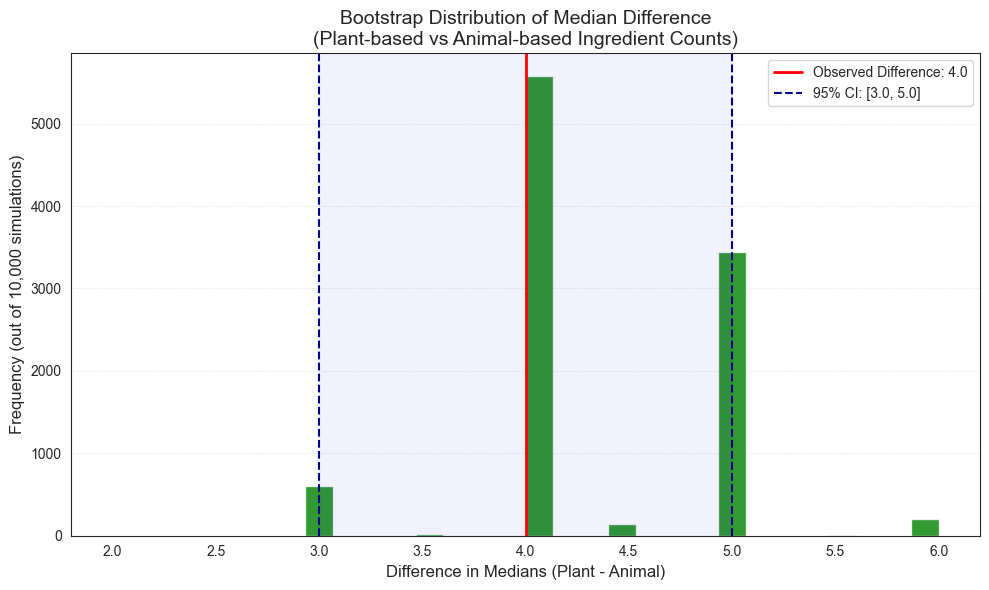

In [35]:
# Set the style
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(10, 6))

# Create the histogram of bootstrap samples
plt.hist(boot_median_diffs, bins=30, color='green', edgecolor='white', alpha=0.8)

# Add vertical line for the observed median difference
plt.axvline(observed_median_diff, color='red', linestyle='-', linewidth=2, 
            label=f'Observed Difference: {observed_median_diff}')

# Add vertical lines for the 95% Confidence Interval
plt.axvline(conf_interval[0], color='darkblue', linestyle='--', linewidth=1.5, 
            label=f'95% CI: [{conf_interval[0]}, {conf_interval[1]}]')
plt.axvline(conf_interval[1], color='darkblue', linestyle='--')

# Shading the Confidence Interval area
plt.axvspan(conf_interval[0], conf_interval[1], color='blue', alpha=0.05)

# Labels and Title
plt.title('Bootstrap Distribution of Median Difference\n(Plant-based vs Animal-based Ingredient Counts)', fontsize=14)
plt.xlabel('Difference in Medians (Plant - Animal)', fontsize=12)
plt.ylabel('Frequency (out of 10,000 simulations)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Bootstrap Results ###

The first observation about this graph is that it appears very different from the other bootstrap distribution. This distribution appears very "chunky" with only a few values on the x-axis. Constructing a 95% confidence interval follows the same procedure despite appearing differently. 95% of the boot samples occur between 3.0 and 5.0 thus, we are 95% confident that the true difference in medians is between 3 and 5 ingredients. In context, a typical plant-based protein drink has 3 to 5 more ingredients than a typical animal-based protein drink. 

#### Central Limit Theorem ####

Unlike the previous bootstrap distribution, this plot clearly does not follow a normal curve. The median does not follow the Central Limit Theorem because it is a discrete value that does not produce a smooth continuous curve. The median number of ingredients of a product can only be a whole number. For example, a product cannot have 3.5 ingredients. This results in a limited number of outcomes and thus, many outcomes are the same. More than half of the bootstraps result in a median difference of 4 ingredients. 

# Conclusion #

This project highlights just a few of the many differences between plant-based and animal-based protein drinks. The first key finding is that animal-based protein drinks generally contain a higher ratio of calories from protein. Second, we are 95% confident that Plant-based drinks contain between 3-4 grams more fiber. Third, we are 95% confident that the median plant-based drink contains 3-5 more ingredients than the median animal-based protein drink. In addition, we briefly explored the lack of complete protein profiles in a large proportion of products- specifically plant-based. While limited, these findings specifically highlight the importance of increased transparency in the protein supplement industry. This project barely scratches the surface - protein drinks are a complex and confusing product. Consumers must be cautious of marketing tactics and misleading numbers. It is ever more important to make informed decisions when consuming these highly processed products. 
